# FRBlip quick start

In [1]:
import numpy as np
import pandas as pd

import frblip as frb

import matplotlib.pyplot as plt

## Create a mock of Cosmic Bursts

In [2]:
mock = frb.blips(random_state=42, duration=460, zmax=1)

get the redshift:

In [3]:
mock.redshift

array([0.92483425, 0.86430586, 0.73637569, ..., 0.40456968, 0.9790652 ,
       0.68144783])

Luminosity distance:

In [4]:
mock.luminosity_distance

<Quantity [6171.96779164, 5679.0172896 , 4666.6225013 , ..., 2271.04050383,
           6620.58166968, 4245.42548729] Mpc>

Note that frblip uses units from astropy package

possible quantities and methods:

In [5]:
mock.igm_dm

<Quantity [ 751.43728818, 1115.18323894, 1009.64935805, ...,  511.23387512,
           1385.94156434, 1066.95707323] pc / cm3>

In [6]:
mock.__dict__.keys()

dict_keys(['duration', 'zmin', 'zmax', 'log_L0', 'log_Lstar', 'phistar', 'gamma', 'w_mean', 'w_std', '_spec_idx_dist', 'ra_range', 'dec_range', 'low_frequency', 'high_frequency', 'low_frequency_cal', 'high_frequency_cal', 'igm_model', 'free_electron_bias', 'cosmology', 'host_dist', 'host_source', 'host_model', 'emission_frame', 'start', 'gal_nside', 'gal_method', 'random_state', 'area', '_xmin', '_lumdist', '_cosmology', '_zdist', 'sky_rate', 'size', 'rate', 'params', 'spectral_index', 'redshift', 'luminosity_distance', 'log_luminosity', '_luminosity', 'flux', '_energy_normalization', '_igm_dm', 'igm_dm'])

Load a Radio Telescope:

In [7]:
bingo = frb.telescope()

Perform observations on a mock

In [8]:
mock.observe(bingo)

Performing observation for telescope OBS_0...
Computing positions for 4835980 sources at site lon=-38.268 deg, lat=-7.041 deg, height=379.000 m.



The results are storage on observations property:

In [9]:
mock.observations

{'OBS_0': <frblip.observation.Observation at 0x7ff515d61f00>}

Computing signal to noise ratio:

In [10]:
mock.signal_to_noise()

Format,coo
Data Type,float64
Shape,"(4835980, 28)"
nnz,922418
Density,0.006812166303417301
Read-only,True
Size,21.1M
Storage ratio,0.0


Note that the information is given as a sparse array. To convert it you must pass True to `todense` argument:

In [11]:
mock.signal_to_noise(todense=True)

<xarray.DataArray (FRB: 4835980, OBS_0: 28)>
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
Dimensions without coordinates: FRB, OBS_0

To compute the total value over beams we pass True to the `total` argument

In [12]:
mock.signal_to_noise(total=True, todense=True)

<xarray.DataArray (FRB: 4835980)>
array([0., 0., 0., ..., 0., 0., 0.])
Dimensions without coordinates: FRB

The function `triggers` returns if a FRB is observed given minima signal to noise values, default value is range(1, 11):

In [13]:
mock.triggers(todense=True)

<xarray.DataArray (FRB: 4835980, OBS_0: 28, SNR: 10)>
array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
...
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]])
Coordinates:
  * SNR      (SNR) int64 1 2 3 4 5 6 7 8 9 10
Dimensions without coordinates: FRB, OBS_0

In [14]:
mock.triggers(todense=True, total=True, snr=range(5, 16))

<xarray.DataArray (FRB: 4835980, SNR: 11)>
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
  * SNR      (SNR) int64 5 6 7 8 9 10 11 12 13 14 15
Dimensions without coordinates: FRB

`counts` method returns the number of observed FRB:

In [15]:
mock.counts()

<xarray.DataArray (OBS_0: 28, SNR: 10)>
array([[ 2,  1,  1,  1,  1,  1,  1,  1,  1,  1],
       [ 6,  4,  4,  3,  2,  2,  2,  2,  2,  2],
       [ 5,  4,  4,  2,  2,  2,  2,  2,  2,  2],
       [ 4,  3,  3,  1,  0,  0,  0,  0,  0,  0],
       [ 9,  7,  5,  4,  3,  3,  3,  3,  3,  2],
       [ 4,  4,  3,  2,  1,  1,  1,  1,  1,  1],
       [ 3,  1,  1,  1,  1,  1,  1,  1,  1,  1],
       [ 3,  1,  1,  1,  1,  1,  1,  1,  1,  0],
       [ 4,  1,  1,  1,  1,  1,  1,  1,  1,  1],
       [ 5,  3,  2,  2,  1,  1,  1,  1,  1,  1],
       [ 7,  5,  4,  3,  3,  3,  3,  3,  3,  3],
       [ 7,  3,  2,  1,  1,  1,  1,  1,  1,  1],
       [ 6,  4,  3,  2,  2,  2,  2,  2,  2,  1],
       [ 6,  3,  1,  1,  1,  1,  1,  1,  1,  1],
       [ 9,  6,  4,  4,  3,  3,  3,  3,  3,  3],
       [13,  7,  5,  5,  5,  3,  3,  3,  3,  3],
       [ 7,  2,  1,  1,  1,  1,  1,  1,  1,  1],
       [ 7,  2,  2,  1,  1,  1,  1,  1,  0,  0],
       [ 8,  5,  3,  2,  2,  2,  2,  2,  2,  2],
       [ 4,  3,  1,  0,  0,  0,  0,  0,  0,  0],
       [ 8,  4,  3,  2,  1,  1,  1,  1,  1,  1],
       [ 8,  5,  5,  4,  4,  4,  4,  3,  3,  2],
       [ 6,  3,  3,  1,  1,  1,  1,  1,  1,  1],
       [ 5,  3,  2,  2,  2,  2,  2,  1,  1,  1],
       [ 7,  2,  1,  1,  1,  0,  0,  0,  0,  0],
       [ 7,  5,  3,  3,  3,  3,  3,  1,  1,  1],
       [ 5,  2,  2,  2,  2,  2,  1,  0,  0,  0],
       [ 3,  3,  3,  3,  2,  0,  0,  0,  0,  0]])
Coordinates:
  * SNR      (SNR) int64 1 2 3 4 5 6 7 8 9 10
Dimensions without coordinates: OBS_0

In [16]:
mock.counts(total=True)

<xarray.DataArray (SNR: 10)>
array([168,  96,  73,  56,  48,  43,  42,  37,  36,  32])
Coordinates:
  * SNR      (SNR) int64 1 2 3 4 5 6 7 8 9 10

In [17]:
mock.counts(total=True, snr=range(5, 16))

<xarray.DataArray (SNR: 11)>
array([48, 43, 42, 37, 36, 32, 26, 24, 24, 22, 20])
Coordinates:
  * SNR      (SNR) int64 5 6 7 8 9 10 11 12 13 14 15

In [18]:
frb_data = mock.catalog()

In [19]:
len(frb_data['redshift'])

168

In [20]:
z = frb_data['redshift']
DM_IGM = frb_data['igm_dm']

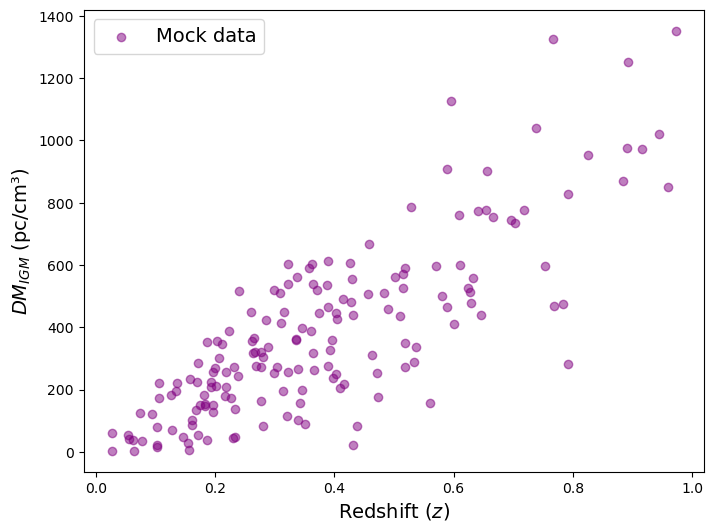

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(z, DM_IGM, color='purple', alpha=0.5, label='Mock data')
plt.xlabel('Redshift ($z$)', fontsize=14)
plt.ylabel('$DM_{IGM}$ (pc/cm³)', fontsize=14)
plt.legend(fontsize=14)
plt.savefig('mock_data_BINGO.png', dpi=600)
plt.show()

In [22]:
# Convertendo DM para um array sem unidades
DM_value = DM_IGM.to_value()  # Remove as unidades, mantendo apenas os valores numéricos

# Combine os arrays em duas colunas
data = np.column_stack((z, DM_value))

# Salve em um arquivo .txt
np.savetxt('data_sim/DM_IGM_sim_455d.txt', data, fmt='%f', delimiter='\t', header='z\tDM')

In [27]:
from astropy.coordinates import SkyCoord
from astropy.visualization import astropy_mpl_style
import astropy.units as u

plt.style.use(astropy_mpl_style)


In [29]:
declination = frb_data['declination']
right_ascension = frb_data['right_ascension']

coords = SkyCoord(ra=right_ascension, dec=declination, frame='icrs')


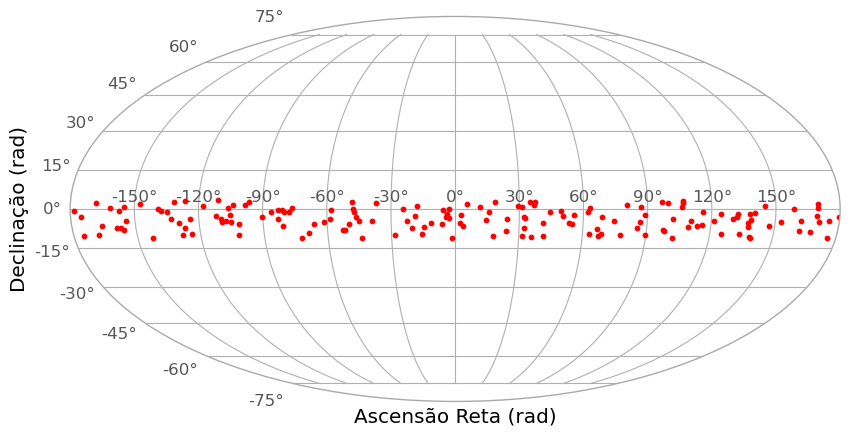

In [42]:
plt.figure(figsize=(10, 5))
plt.subplot(111, projection="mollweide")

# Converter RA para radianos e ajustar para o formato da projeção
ra_rad = coords.ra.wrap_at(180 * u.deg).radian
dec_rad = coords.dec.radian

plt.scatter(ra_rad, dec_rad, color='red', marker='o', s=10)  # Ajuste as cores e tamanho dos marcadores conforme necessário
plt.grid(True)

plt.xlabel('Ascensão Reta (rad)')
plt.ylabel('Declinação (rad)')
#plt.title('Mapa do Céu')
plt.show()